# SBC-Dilution — a quantitative teardown 🔬
### dilution score (z(SBC/rev)+z(share growth)) · annual sort · one-sample *t* · label-shuffle placebo · each-leg & width robustness · costs & borrow · synthetic control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Replicates_here%3F: Busted](https://img.shields.io/badge/Replicates_here%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim now carrying its standard error.* We build an SBC/dilution score, sort the cross-section annually, and test whether the lean names beat the heavy diluters (the anomaly) — or, here, the reverse.

> ⚠️ **Not investment advice.** Real data: yfinance year-end prices + split-adjusted shares + an SBC/revenue snapshot, 31 survivors (as-of 2026-06-30, joint panel fp `bbec9e324ac1`); the offline core and tests run on a deterministic synthetic world. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back into intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from sbc_dilution import data, strategy as st

def load_real():
    """Cache-first real (prices, shares, sbc); drop the partial current year."""
    if not data.have_real():
        return None
    px, sh, sbc = data.load_real()
    return data.drop_partial_last_year(px, sh, sbc, asof=pd.Timestamp("2026-06-30"))

REAL = load_real()
HAVE_REAL = REAL is not None
if HAVE_REAL:
    PX, SH, SBC = REAL
    print("real SBC/dilution panel present:", HAVE_REAL,
          f"({PX.shape[1]} names, formation {PX.index[0].year+1} -> {PX.index[-1].year})")
else:
    print("real panel absent — using frozen headline numbers (offline)")


real SBC/dilution panel present: True (31 names, formation 2015 -> 2025)


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Long-lean / short-diluters spread **-15.2%/yr** (one-sample *t* **-2.01**, placebo *p* 0.998) — the *wrong* sign; wins 22% of years; wrong sign in every leg & width. |
| **Tradability** | `MIRAGE` | Survivor basket, annual rebalance, diluter short = costly borrow. Gross -15.2% → net -15.9% (10 bps/leg + 50 bps borrow). |
| **Replicates here?** | `BUSTED` | A canonical accounting factor, honestly replicated on a small survivor basket over an AI melt-up, inverts — sign reverses, *t* never clears +2, placebo unbeaten. |

> 💡 In plain words: the engine works (the synthetic control proves it, with the *right* sign), but on this survivor basket over this window the anomaly is inverted and stably so.

## 1 · The claim, steelmanned

Let $D_i$ be firm $i$'s dilution score (heavy SBC + fast share growth) and $r_i$ its next-year return.

- **H₁ (the anomaly / long-short).** $\mathbb{E}[r \mid \text{lean}] - \mathbb{E}[r \mid \text{diluter}] > 0$ at *t* ≥ 2 (lean beats diluters).
- **H₂ (each leg).** The sign holds for SBC-intensity alone *and* share-growth alone.
- **H₃ (robustness).** The sign is stable across quantile widths.
- **H₄ (net).** H₁ survives costs and the diluter-leg borrow.

We find **H₁ rejected** (wrong sign, *t* −2.0), **H₂ rejected** (both legs negative), **H₃ rejected the wrong way** (stably negative), and **H₄ moot** (the trade is the wrong sign before costs).

## 2 · So what? — what rides on each answer

The content is the **why**. The SBC/dilution anomaly is documented on full-universe, survivorship-free data driven by firms that over-issue and disappoint. Two forces kill it here: (a) **survivorship** — the basket already dropped every firm that diluted itself to death, removing the left tail that makes diluters lose on average; and (b) an **AI/growth melt-up** (2020-24) that rewarded the SBC-heavy mega-caps the score flags as diluters. That echoes [519 Net-Share-Issuance](../../519-net-share-issuance/) and [540 Distress-Risk](../../540-distress-risk-anomaly/), which invert on the same kind of survivor tape.

## 3 · How we'd know — the protocol

- **Score.** $D = z(\text{SBC}/\text{rev}) + z(\Delta\text{shares})$, each z-scored across the basket each year (higher = more dilutive). Shares are **split-adjusted** so a split isn't mistaken for issuance.
- **Sort.** Tercile tails (≈9 names each): lean (lowest $D$) vs diluters (highest).
- **Inference.** One-sample *t* of the annual long-short mean vs 0; a **label-shuffle placebo** null (permute which name carries which score).
- **Robustness.** Each leg alone (SBC-only, dilution-only); a quantile-width sweep.
- **Frictions.** One-way cost × turnover on both legs + an annual borrow on the diluter short.
- **Positive control.** A deterministic synthetic world with a planted anomaly (`edge > 0`, heavy-diluters underperform) and a null — averaged over 25 seeds (house rule).

Timing: the score is public at year-end *t*; we trade *t→t+1* and hold (one execution lag). No future data enters the score. **Data limits, named:** yfinance exposes only a shallow ~4-year SBC history, so the SBC leg is a recent snapshot forward-filled onto the grid; the basket is large-cap **survivors**. Both cap the stamp — a survivor / snapshot study can never be `REAL`.

## 4 · The teardown

### 4a · The sort — H₁

Lean vs diluter next-year returns, with the one-sample *t* and the placebo null.

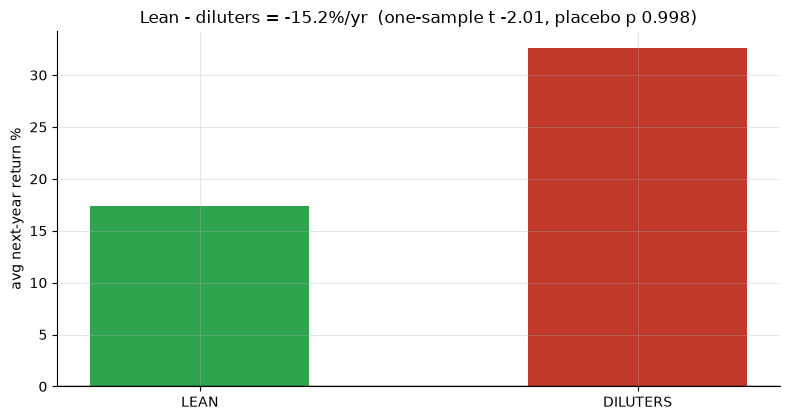

Lean +17.4%/yr | Diluters +32.6%/yr | LS -15.2%/yr | t -2.01 | placebo p 0.998


In [2]:
if HAVE_REAL:
    s = st.summarize(PX, SH, SBC, frac=0.3, placebo=True)
    lean_m, dil_m, ls, t, p = (s['long_mean']*100, s['short_mean']*100, s['ls_mean']*100,
                               s['t'], s['p_placebo'])
else:
    lean_m, dil_m, ls, t, p = 17.4, 32.6, -15.2, -2.01, 0.998
fig, ax = plt.subplots(figsize=(8, 4.3))
ax.bar(['LEAN','DILUTERS'], [lean_m, dil_m], color=[GREEN, RED], width=.5)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('avg next-year return %')
ax.set_title(f'Lean - diluters = {ls:+.1f}%/yr  (one-sample t {t:+.2f}, placebo p {p:.3f})')
plt.tight_layout(); plt.show()
print(f'Lean +{lean_m:.1f}%/yr | Diluters +{dil_m:.1f}%/yr | LS {ls:+.1f}%/yr | t {t:+.2f} | placebo p {p:.3f}')

> 💡 In plain words: H₁ **rejected, with the sign reversed.** The spread is **-15.2%/yr** (*t* -2.01), and the placebo *p* = 0.998 says the real sort is worse than 998 of every 1000 random relabellings — the diluters genuinely *out*-earned the lean names on this window.

### 4b · Each leg alone — H₂

Does the sign survive when we sort on SBC intensity alone, or share growth alone?

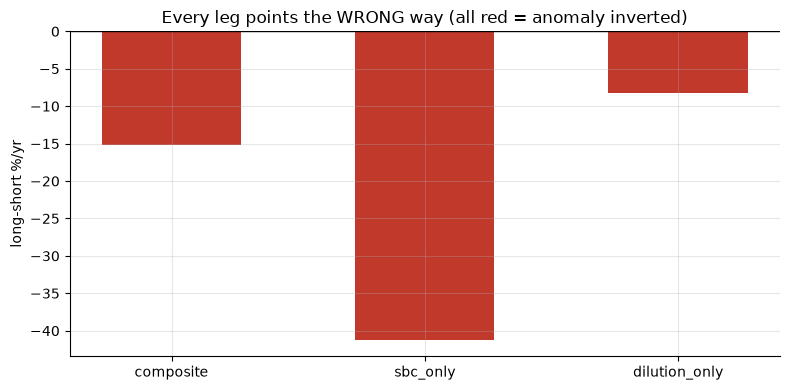

               years  ls_mean%     t
leg                                 
composite          9    -15.18 -2.01
sbc_only           3    -41.30 -1.92
dilution_only      9     -8.19 -1.37


In [3]:
legs = [('composite', 9, -15.2, -2.01), ('SBC-only', 3, -41.3, -1.92), ('dilution-only', 9, -8.2, -1.37)]
if HAVE_REAL:
    rows = [(r['signal'], r['n_years'], r['ls_mean']*100, r['t'])
            for r in st.leg_sweep(PX, SH, SBC, frac=0.3)]
else:
    rows = legs
tab = pd.DataFrame(rows, columns=['leg','years','ls_mean%','t']).set_index('leg')
fig, ax = plt.subplots(figsize=(8, 4.0))
cols = [GREEN if v>0 else RED for v in tab['ls_mean%']]
ax.bar(range(len(tab)), tab['ls_mean%'], color=cols, width=.55)
ax.set_xticks(range(len(tab))); ax.set_xticklabels(tab.index)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('long-short %/yr')
ax.set_title('Every leg points the WRONG way (all red = anomaly inverted)')
plt.tight_layout(); plt.show()
print(tab.round(2).to_string())

> 💡 In plain words: H₂ **rejected.** Composite **−15.2%**, SBC-only **−41.3%** (3 snapshot years), dilution-only **−8.2%** — all negative. A hidden cost being under-priced would show a *positive* spread in at least one leg; none does.

### 4c · Robustness — H₃ (does the width matter?)

The same sort at three quantile widths.

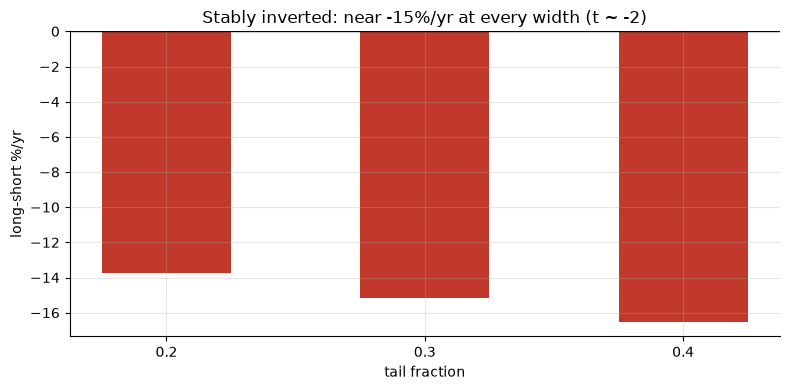

      ls_mean%     t
frac                
0.2     -13.76 -1.91
0.3     -15.18 -2.01
0.4     -16.53 -1.99


In [4]:
widths = [(0.2, -13.8, -1.91), (0.3, -15.2, -2.01), (0.4, -16.5, -1.99)]
if HAVE_REAL:
    rows = [(r['frac'], r['ls_mean']*100, r['t']) for r in st.width_sweep(PX, SH, SBC)]
else:
    rows = widths
tab = pd.DataFrame(rows, columns=['frac','ls_mean%','t']).set_index('frac')
fig, ax = plt.subplots(figsize=(8, 4.0))
ax.bar([str(f) for f in tab.index], tab['ls_mean%'], color=RED, width=.5)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('long-short %/yr'); ax.set_xlabel('tail fraction')
ax.set_title('Stably inverted: near -15%/yr at every width (t ~ -2)')
plt.tight_layout(); plt.show()
print(tab.round(2).to_string())

> 💡 In plain words: H₃ **rejected the wrong way.** The inversion isn't a tail-width artefact — it's the same, near *t* −2, at 20/30/40% cuts. Stable, but stably backwards.

## 5 · The verdict

- **Signal `NONE`** — H₁ rejected (spread -15.2%, *t* -2.01, wrong sign); H₂ rejected (every leg negative); H₃ rejected (stably inverted).
- **Tradability `MIRAGE`** — survivor basket, annual rebalance, diluter-leg borrow; gross -15.2% → net -15.9%.
- **Replicates here? `BUSTED`** — the full-market anomaly inverts on 31 survivors.

## 6 · Could you trade it? — costs and the borrow

The trade is the wrong sign before costs; the borrow just deepens it.

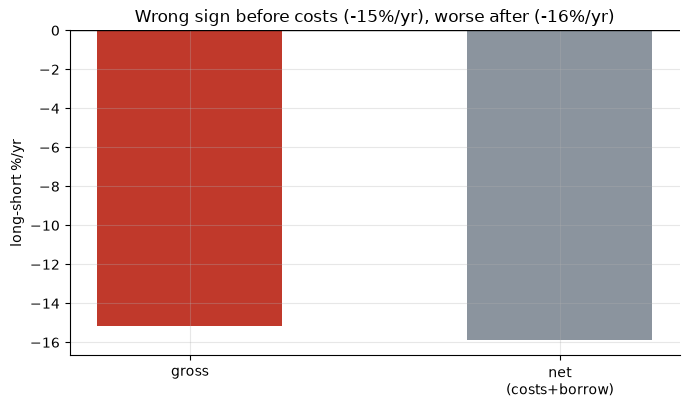

gross -15.2%/yr -> net -15.9%/yr (10 bps/leg x 2 + 50 bps borrow)


In [5]:
if HAVE_REAL:
    c = st.net_of_costs(PX, SH, SBC, frac=0.3, cost_bps=10.0, borrow_ann_bps=50.0)
    gross, net = c['gross_mean']*100, c['net_mean']*100
else:
    gross, net = -15.2, -15.9
fig, ax = plt.subplots(figsize=(7, 4.2))
ax.bar(['gross','net\n(costs+borrow)'], [gross, net], color=[RED, GREY], width=.5)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('long-short %/yr')
ax.set_title(f'Wrong sign before costs ({gross:+.0f}%/yr), worse after ({net:+.0f}%/yr)')
plt.tight_layout(); plt.show()
print(f'gross {gross:+.1f}%/yr -> net {net:+.1f}%/yr (10 bps/leg x 2 + 50 bps borrow)')

> 💡 In plain words: there is nothing to charge costs against — the long-lean / short-diluters book *loses* before frictions on this window. `MIRAGE`.

## 7 · Going further — the synthetic positive control

Is the engine a faithful detector, or does it always print ~0? Plant a real anomaly (`edge > 0`, heavy-diluters underperform) of increasing strength and watch the long-short *t* go **positive** — averaged over 25 seeds so no single lucky seed can fake it.

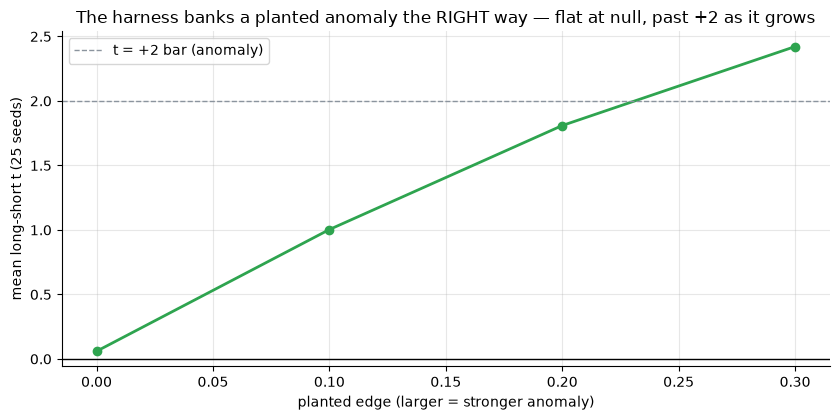

edge +0.00 -> mean t +0.06, ls_mean -0.3%
edge +0.10 -> mean t +1.00, ls_mean +4.8%
edge +0.20 -> mean t +1.81, ls_mean +9.9%
edge +0.30 -> mean t +2.42, ls_mean +15.0%


In [6]:
ctrl = [(0.0, 0.06, -0.3), (0.1, 1.0, 4.8), (0.2, 1.81, 9.9), (0.3, 2.42, 15.0)]
edges = [0.0, 0.10, 0.20, 0.30]
rows = [st.synthetic_control(data.synthetic_panel, edges=[e], n_years=6, n_seeds=25)[0]
        for e in edges]
ts = [r['mean_t'] for r in rows]
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.plot(edges, ts, 'o-', c=GREEN, lw=2)
ax.axhline(2, ls='--', c=GREY, lw=1, label='t = +2 bar (anomaly)')
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('planted edge (larger = stronger anomaly)')
ax.set_ylabel('mean long-short t (25 seeds)')
ax.set_title('The harness banks a planted anomaly the RIGHT way — flat at null, past +2 as it grows')
ax.legend(); plt.tight_layout(); plt.show()
for e, r in zip(edges, rows): print(f"edge {e:+.2f} -> mean t {r['mean_t']:+.2f}, ls_mean {r['ls_mean']*100:+.1f}%")

The long-short *t* is ≈ 0 at the null and rises past **+2** as the planted anomaly grows — so the engine is a faithful detector *and* points the right way when the effect is real. The real-tape **negative** *t* is therefore a statement about **this survivor basket on this window**: the SBC/dilution anomaly is inverted and stably so here. For the pure share-count cousin, see [519 Net-Share-Issuance](../../519-net-share-issuance/).